In [1]:
!pip install shap lime scikit-image -q

In [2]:
import os, io, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import scipy.io as sio
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image

import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries, quickshift

import ipywidgets as widgets
from IPython.display import display, clear_output

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')

PyTorch : 2.10.0+cu128
CUDA    : True


In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR   = "/kaggle/input/datasets/userisakid/augmented-figshare-dataset"
TEST_DIR   = os.path.join(DATA_DIR, "test")   # ← TESTING ONLY on test split
MODEL_PATH = '/kaggle/input/notebooks/userisakid/resnet101-v1/best_resnet101.pth'

# ── Model / Data settings ──────────────────────────────────────────────────
CLASS_NAMES   = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
NUM_CLASSES   = len(CLASS_NAMES)
IMG_SIZE      = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Sampling (from test set only) ──────────────────────────────────────────
N_PER_CLASS = 2   # images per class from TEST set only

# ── LIME hyper-parameters (tuned for accuracy) ────────────────────────────
LIME_NUM_SAMPLES  = 2000   # ↑ more samples → more accurate
LIME_NUM_FEATURES = 12     # top superpixels to highlight
LIME_BATCH_SIZE   = 64

# ── SHAP settings ──────────────────────────────────────────────────────────
SHAP_BG_SIZE = 40          # ↑ larger background → more stable SHAP values

print(f'Device      : {DEVICE}')
print(f'Classes     : {CLASS_NAMES}')
print(f'Test dir    : {TEST_DIR}')
print(f'SHAP bg     : {SHAP_BG_SIZE} images')
print(f'LIME samples: {LIME_NUM_SAMPLES}')

Device      : cuda
Classes     : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Test dir    : /kaggle/input/datasets/userisakid/augmented-figshare-dataset/test
SHAP bg     : 40 images
LIME samples: 2000


In [5]:
# ─────────────────────────────────────────────────────────────────
#  OPTION A: Import from torchvision and customise
# ─────────────────────────────────────────────────────────────────
#  Uncomment the block that matches YOUR model, or write your own.
# ─────────────────────────────────────────────────────────────────

# ── EfficientNetB0 ───────────────────────────────────────────────
# from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# def build_model():
#     m = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
#     in_features = m.classifier[1].in_features
#     m.classifier = nn.Sequential(
#         nn.Dropout(p=0.3, inplace=True),
#         nn.Linear(in_features, NUM_CLASSES)
#     )
#     return m

# def get_target_layer(model):
#     """Return the conv layer for Grad-CAM. Change per model architecture."""
#     return model.features[8][0]   # EfficientNetB0 last conv block


# ── DenseNet121  (uncomment to use) ─────────────────────────────
# from torchvision.models import densenet121, DenseNet121_Weights
# def build_model():
#     m = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
#     m.classifier = nn.Linear(m.classifier.in_features, NUM_CLASSES)
#     return m
# def get_target_layer(model):
#     return model.features.denseblock4.denselayer16.conv2  # last DenseNet conv


# ── ResNet101  (uncomment to use) ────────────────────────────────
from torchvision.models import resnet101, ResNet101_Weights
def build_model():
    m = resnet101(weights=ResNet101_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m
def get_target_layer(model):
    return model.layer4[-1].conv3   # last ResNet bottleneck conv


# ── VGG16  (uncomment to use) ────────────────────────────────────
# from torchvision.models import vgg16, VGG16_Weights
# def build_model():
#     m = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
#     m.classifier[6] = nn.Linear(4096, NUM_CLASSES)
#     return m
# def get_target_layer(model):
#     return model.features[28]       # last VGG conv layer


# ── MobileNetV3-Large  (uncomment to use) ────────────────────────
# from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
# def build_model():
#     m = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1)
#     m.classifier[3] = nn.Linear(m.classifier[3].in_features, NUM_CLASSES)
#     return m
# def get_target_layer(model):
#     return model.features[-1][0]    # last conv in MobileNetV3


# ── Custom / Imported model  (uncomment to use) ──────────────────
# import sys; sys.path.insert(0, '/path/to/your/model/folder')
# from my_model import MyNet
# def build_model():
#     return MyNet(num_classes=NUM_CLASSES)
# def get_target_layer(model):
#     return model.backbone.layer4[-1]   # ← adjust to your arch


print('build_model and get_target_layer defined')

build_model and get_target_layer defined


In [6]:
model        = build_model()
target_layer = get_target_layer(model)

if os.path.exists(MODEL_PATH):
    state = torch.load(MODEL_PATH, map_location=DEVICE)
    # Handle state dicts wrapped in 'model_state_dict' or 'state_dict' keys
    if isinstance(state, dict):
        for key in ('model_state_dict', 'state_dict', 'model'):
            if key in state:
                state = state[key]
                print(f'  (extracted key "{key}" from checkpoint)')
                break
    model.load_state_dict(state, strict=False)
    print(f'✅ Loaded weights from {MODEL_PATH}')
else:
    print(f'⚠️  {MODEL_PATH} not found — using pretrained weights only.')

model = model.to(DEVICE)
model.eval()
print(f'Model ready on {DEVICE}')
print(f'   Grad-CAM target layer: {target_layer}')

Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:00<00:00, 199MB/s]  


✅ Loaded weights from /kaggle/input/notebooks/userisakid/resnet101-v1/best_resnet101.pth
Model ready on cuda
   Grad-CAM target layer: Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [8]:
infer_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


def mat_to_pil(src):
    """Load .mat file (filepath str or raw bytes) → PIL RGB."""
    open_fn = (lambda: sio.loadmat(src))          if isinstance(src, str) \
              else (lambda: sio.loadmat(io.BytesIO(src)))
    h5_fn   = (lambda: h5py.File(src, 'r'))       if isinstance(src, str) \
              else (lambda: h5py.File(io.BytesIO(src), 'r'))
    try:
        mat     = open_fn()
        img_raw = mat['cjdata']['image'][0, 0].astype(np.float32)
    except Exception:
        with h5_fn() as f:
            img_raw = np.array(f['cjdata']['image']).astype(np.float32).T
    mn, mx = img_raw.min(), img_raw.max()
    img_u8 = ((img_raw - mn) / (mx - mn + 1e-8) * 255).astype(np.uint8)
    return Image.fromarray(img_u8, 'L').convert('RGB')


def load_any_image(src, filename=None):
    """Load image from filepath str (.mat/.png/.jpg) or raw bytes."""
    if isinstance(src, str):
        ext = os.path.splitext(src)[1].lower()
        if ext == '.mat':
            return mat_to_pil(src)
        return Image.open(src).convert('RGB')
    else:
        fname = (filename or '').lower()
        if fname.endswith('.mat'):
            return mat_to_pil(src)
        return Image.open(io.BytesIO(src)).convert('RGB')


def denormalize(tensor):
    """Undo ImageNet normalisation → numpy (H, W, 3) in [0, 1]."""
    mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
    std  = np.array(IMAGENET_STD).reshape(3, 1, 1)
    img  = tensor.cpu().numpy() * std + mean
    return np.clip(img, 0, 1).transpose(1, 2, 0)


def build_file_list(split_dir):
    """Collect (filepath, label_idx) for all images in split_dir."""
    file_list = []
    for label_idx, cls in enumerate(CLASS_NAMES):
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in sorted(os.listdir(cls_dir)):
            if fname.lower().endswith(('.mat', '.png', '.jpg', '.jpeg')):
                file_list.append((os.path.join(cls_dir, fname), label_idx))
    return file_list


# ── Build TEST-ONLY file lists ─────────────────────────────────────────────
test_files = build_file_list(TEST_DIR)
per_class  = {i: [] for i in range(NUM_CLASSES)}
for fpath, lbl in test_files:
    per_class[lbl].append(fpath)

print(f'Test files total: {len(test_files)}')
for i, cls in enumerate(CLASS_NAMES):
    print(f'  {cls:<15s}: {len(per_class[i])} files')


def sample_balanced(n_per_class=N_PER_CLASS):
    """Return equal-count random sample from each TEST class."""
    sampled = []
    for i, cls in enumerate(CLASS_NAMES):
        picks = random.sample(per_class[i], min(n_per_class, len(per_class[i])))
        sampled.extend([(p, i) for p in picks])
    random.shuffle(sampled)
    return sampled


print(f'\nBalanced sample: {N_PER_CLASS} per class = {N_PER_CLASS * NUM_CLASSES} total (TEST only)')

Test files total: 560
  glioma         : 140 files
  meningioma     : 140 files
  no_tumor       : 140 files
  pituitary      : 140 files

Balanced sample: 2 per class = 8 total (TEST only)


In [9]:
def run_gradcam(pil_rgb):
    gradients, activations = {}, {}

    fwd = target_layer.register_forward_hook(
        lambda m, i, o: activations.update({'v': o.detach()}))
    bwd = target_layer.register_full_backward_hook(
        lambda m, gi, go: gradients.update({'v': go[0].detach()}))

    inp    = infer_tf(pil_rgb).unsqueeze(0).to(DEVICE)
    output = model(inp)
    probs  = F.softmax(output, dim=1).squeeze().detach().cpu().numpy()
    pred_idx = int(np.argmax(probs))

    model.zero_grad()
    output[0, pred_idx].backward()

    grads = gradients['v']
    acts  = activations['v']

    w   = grads.mean(dim=[2, 3], keepdim=True)
    cam = F.relu((w * acts).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, (IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    fwd.remove()
    bwd.remove()
    return cam, pred_idx, probs


def overlay_cam(img_np, heatmap, alpha=0.50):
    h     = plt.cm.jet(heatmap)[..., :3]
    img_f = img_np.astype(np.float32) / 255.
    return np.clip(alpha * h + (1 - alpha) * img_f, 0, 1)


print('Grad-CAM functions ready')

Grad-CAM functions ready


In [10]:
# ── SHAP background: exactly BG_SIZE // NUM_CLASSES images per class ──────
BG_PER_CLASS = SHAP_BG_SIZE // NUM_CLASSES   # e.g. 40 // 4 = 10 per class

_bg_paths = []
for cls_idx in range(NUM_CLASSES):
    cls_pool = per_class[cls_idx]             # already built from TEST_DIR
    n_pick   = min(BG_PER_CLASS, len(cls_pool))
    _bg_paths.extend(random.sample(cls_pool, n_pick))

random.shuffle(_bg_paths)

_bg_tensors = torch.stack([
    infer_tf(load_any_image(p, p))
    for p in _bg_paths
]).to(DEVICE)

shap_explainer = shap.GradientExplainer(model, _bg_tensors)

actual_bg = len(_bg_paths)
print(f'SHAP GradientExplainer ready')
print(f'   Background: {actual_bg} test images ({BG_PER_CLASS} per class × {NUM_CLASSES} classes)')
for i, cls in enumerate(CLASS_NAMES):
    n = sum(1 for p in _bg_paths if p in per_class[i])
    print(f'   {cls:<15s}: {n} images')


def run_shap(pil_rgb):
    t         = infer_tf(pil_rgb).unsqueeze(0).to(DEVICE)
    shap_vals = shap_explainer.shap_values(t)

    if isinstance(shap_vals, list):
        shap_arr = np.stack(shap_vals, axis=-1)
    else:
        shap_arr = shap_vals

    with torch.no_grad():
        probs    = F.softmax(model(t), dim=1).squeeze().cpu().numpy()
    pred_idx = int(np.argmax(probs))

    sv       = shap_arr[0, :, :, :, pred_idx]   # (C, H, W)
    shap_map = sv.mean(axis=0)                   # (H, W)
    return shap_map, pred_idx, probs


def plot_shap_beeswarm_overlay(ax, img_np, shap_map, dot_size=2, alpha_scatter=0.75):
    ax.imshow(img_np.astype(np.uint8), alpha=0.85)

    h, w      = shap_map.shape
    ys, xs    = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    flat_vals = shap_map.flatten()
    flat_xs   = xs.flatten()
    flat_ys   = ys.flatten()

    K       = min(600, len(flat_vals))
    top_idx = np.argsort(np.abs(flat_vals))[-K:]
    vals_k  = flat_vals[top_idx]
    xs_k    = flat_xs[top_idx]
    ys_k    = flat_ys[top_idx]

    vmax      = np.abs(vals_k).max() + 1e-8
    norm_vals = vals_k / vmax   # (K,) in [-1, 1]

    # Red = positive SHAP (+), Green = negative SHAP (-)
    pos_mask   = norm_vals > 0                               # (K,)
    rgba_red   = plt.cm.Reds(np.clip(norm_vals,   0, 1))    # (K, 4)
    rgba_green = plt.cm.Greens(np.clip(-norm_vals, 0, 1))   # (K, 4)
    colors     = np.where(pos_mask[:, None], rgba_red, rgba_green)  # (K, 4)

    # Small dots, size still scales with |importance|
    sizes = (np.abs(norm_vals) ** 0.5) * dot_size * 12

    ax.scatter(xs_k, ys_k, c=colors, s=sizes,
               alpha=alpha_scatter, linewidths=0, rasterized=True)
    ax.axis('off')

    from matplotlib.lines import Line2D
    ax.legend(handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor='red',   markersize=6, label='+SHAP'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='green', markersize=6, label='-SHAP'),
    ], fontsize=6, loc='lower right', framealpha=0.8)


print('SHAP overlay: red/green small dots')

SHAP GradientExplainer ready
   Background: 40 test images (10 per class × 4 classes)
   glioma         : 10 images
   meningioma     : 10 images
   no_tumor       : 10 images
   pituitary      : 10 images
SHAP overlay: red/green small dots


In [11]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

lime_explainer = lime_image.LimeImageExplainer(verbose=False)


def lime_predict_fn(images_np):
    probs_list = []
    for start in range(0, len(images_np), LIME_BATCH_SIZE):
        batch_np = images_np[start:start + LIME_BATCH_SIZE]
        tensors  = torch.stack([
            infer_tf(Image.fromarray(img.astype(np.uint8)))
            for img in batch_np
        ]).to(DEVICE)
        with torch.no_grad():
            probs = F.softmax(model(tensors), dim=1).cpu().numpy()
        probs_list.append(probs)
    return np.concatenate(probs_list, axis=0)


def run_lime(pil_rgb):
    """
    Run LIME with finer superpixels (quickshift kernel_size=2, max_dist=50)
    and more samples for improved accuracy.
    """
    img_resized = pil_rgb.resize((IMG_SIZE, IMG_SIZE))
    img_np      = np.array(img_resized)

    with torch.no_grad():
        t     = infer_tf(img_resized).unsqueeze(0).to(DEVICE)
        probs = F.softmax(model(t), dim=1).squeeze().cpu().numpy()
    pred_idx = int(np.argmax(probs))

    # Finer segmentation: smaller kernel_size + max_dist → more, smaller superpixels
    from skimage.segmentation import quickshift as qs_seg
    segments = qs_seg(img_np, kernel_size=2, max_dist=50, ratio=0.2)

    explanation = lime_explainer.explain_instance(
        img_np,
        lime_predict_fn,
        top_labels         = NUM_CLASSES,
        hide_color         = 0,
        num_samples        = LIME_NUM_SAMPLES,
        batch_size         = LIME_BATCH_SIZE,
        segmentation_fn    = lambda x: qs_seg(x, kernel_size=2,
                                               max_dist=50, ratio=0.2),
    )
    return explanation, pred_idx, probs, img_np


def get_lime_overlays(explanation, pred_idx, num_features=LIME_NUM_FEATURES):
    img_np = (explanation.image * 255).astype(np.uint8)
    seg    = explanation.segments
    vals   = dict(explanation.local_exp[pred_idx])

    # Signed heatmap
    heatmap = np.zeros(seg.shape, dtype=np.float32)
    for seg_id, weight in vals.items():
        heatmap[seg == seg_id] = weight

    # Positive-only
    pos_mask = np.zeros(seg.shape, dtype=bool)
    top_pos  = sorted([(w, s) for s, w in vals.items() if w > 0],
                       reverse=True)[:num_features]
    for _, s in top_pos:
        pos_mask[seg == s] = True

    pos_rgb            = img_np.copy().astype(np.float32) / 255.0
    pos_rgb[~pos_mask] = 0.12
    pos_rgb = mark_boundaries(pos_rgb, pos_mask.astype(int),
                               color=(0.1, 1.0, 0.2), mode='thick')

    # Both signs
    neg_mask = np.zeros(seg.shape, dtype=bool)
    top_neg  = sorted([(abs(w), s) for s, w in vals.items() if w < 0],
                       reverse=True)[:num_features]
    for _, s in top_neg:
        neg_mask[seg == s] = True

    both_rgb           = img_np.copy().astype(np.float32) / 255.0
    both_rgb[pos_mask] = np.clip(both_rgb[pos_mask] * [0.0, 1.5, 0.0], 0, 1)
    both_rgb[neg_mask] = np.clip(both_rgb[neg_mask] * [1.5, 0.0, 0.0], 0, 1)
    both_rgb = mark_boundaries(both_rgb, pos_mask.astype(int),
                                color=(0.1, 1.0, 0.2), mode='thick')
    both_rgb = mark_boundaries(both_rgb, neg_mask.astype(int),
                                color=(1.0, 0.1, 0.1), mode='thick')

    return heatmap, pos_rgb, both_rgb


print('LIME functions ready (finer superpixels, thick boundaries)')

LIME functions ready (finer superpixels, thick boundaries)


In [12]:
def plot_xai_panel(pil_rgb, true_lbl=None, title_prefix='', save_path=None):
    """
    Columns: Raw Image | Class Probs | Grad-CAM | SHAP (bold dots) |
             LIME Heatmap | LIME Top Support
    Testing uses TEST-only images.
    """
    img_224 = np.array(pil_rgb.resize((IMG_SIZE, IMG_SIZE)))

    cam, pred_gc, probs_gc     = run_gradcam(pil_rgb)
    shap_map, pred_shap, _     = run_shap(pil_rgb)
    explanation, pred_lime, probs_lime, _ = run_lime(pil_rgb)

    votes    = [pred_gc, pred_shap, pred_lime]
    pred_idx = max(set(votes), key=votes.count)
    probs    = probs_gc
    pred_name = CLASS_NAMES[pred_idx]

    bar_cols = ['steelblue'] * NUM_CLASSES
    bar_cols[pred_idx] = 'tomato'

    if true_lbl is not None:
        correct = '✓' if pred_idx == true_lbl else '✗'
        color   = 'green' if pred_idx == true_lbl else 'crimson'
        if pred_idx != true_lbl:
            bar_cols[true_lbl] = 'limegreen'
        sup = f'{title_prefix}  True: {CLASS_NAMES[true_lbl].upper()} | Pred: {pred_name.upper()} {correct}'
    else:
        color = 'darkblue'
        sup   = f'{title_prefix}  Pred: {pred_name.upper()} ({probs[pred_idx]*100:.1f}%)'

    heatmap, lime_pos, lime_both = get_lime_overlays(explanation, pred_idx)

    vmax   = np.abs(shap_map).max() + 1e-8
    vmax_l = np.abs(heatmap).max()   + 1e-8

    fig, axes = plt.subplots(1, 6, figsize=(24, 4.2), dpi=110)
    fig.suptitle(sup, fontsize=13, fontweight='bold', color=color, y=1.04)

    col_titles = ['Raw Image', 'Class Probs', 'Grad-CAM',
                  'SHAP (Bold Dots)', 'LIME Heatmap', 'LIME Top Support']
    for ax, t in zip(axes, col_titles):
        ax.set_title(t, fontsize=10, fontweight='bold', pad=6)

    # 0 — Raw Image
    if img_224.ndim == 3 and img_224[:, :, 0].std() < 5:
        axes[0].imshow(img_224[:, :, 0], cmap='gray')
    else:
        axes[0].imshow(img_224)
    axes[0].axis('off')

    # 1 — Class Probs
    bars = axes[1].barh(CLASS_NAMES, probs, color=bar_cols, edgecolor='white', height=0.55)
    axes[1].set_xlim(0, 1.05)
    axes[1].set_xlabel('Probability', fontsize=8)
    axes[1].tick_params(labelsize=8)
    for bar, prob in zip(bars, probs):
        axes[1].text(min(prob + 0.02, 1.0), bar.get_y() + bar.get_height() / 2,
                     f'{prob:.2f}', va='center', fontsize=7, fontweight='bold')

    # 2 — Grad-CAM
    axes[2].imshow(overlay_cam(img_224, cam))
    axes[2].axis('off')

    # 3 — SHAP bold beeswarm dots
    plot_shap_beeswarm_overlay(axes[3], img_224, shap_map, dot_size=9, alpha_scatter=0.90)
    from matplotlib.lines import Line2D
    legend_elems = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='crimson',  markersize=7, label='+SHAP'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=7, label='−SHAP'),
    ]
    axes[3].legend(handles=legend_elems, fontsize=6, loc='lower right', framealpha=0.75)

    # 4 — LIME Heatmap both signs
    axes[4].imshow(lime_both)
    axes[4].axis('off')
    green_p = mpatches.Patch(color='lime',  label='supports')
    red_p   = mpatches.Patch(color='tomato', label='opposes')
    axes[4].legend(handles=[green_p, red_p], fontsize=6, loc='lower right', framealpha=0.75)

    # 5 — LIME Top Support
    axes[5].imshow(lime_pos)
    axes[5].axis('off')

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=110, bbox_inches='tight')
        print(f'    💾 Saved → {save_path}')
    plt.show()
    return fig


print('plot_xai_panel() ready')

plot_xai_panel() ready



🔬 Running XAI on 8 TEST images (2 per class)
   LIME samples: 2000 | SHAP background: 40
   Estimated time: ~32s GPU / ~200s CPU

  [1/8] glioma — GLIOMA_0084.mat


  0%|          | 0/2000 [00:00<?, ?it/s]

    💾 Saved → /kaggle/working/xai_test_01_glioma.png


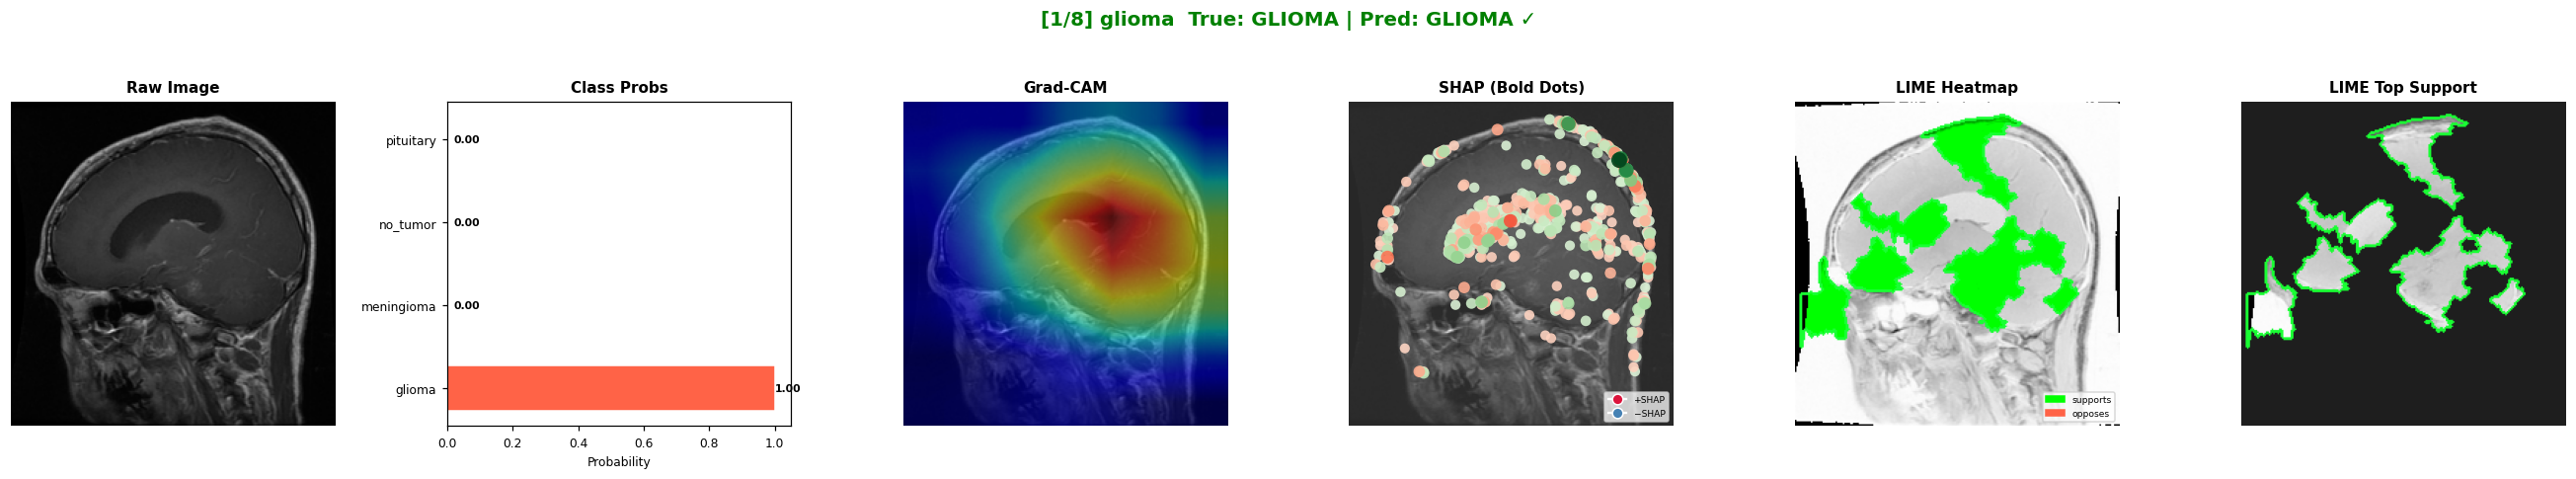

    ✅ Done
  [2/8] pituitary — PITUITARY_0017.mat


  0%|          | 0/2000 [00:00<?, ?it/s]

    💾 Saved → /kaggle/working/xai_test_02_pituitary.png


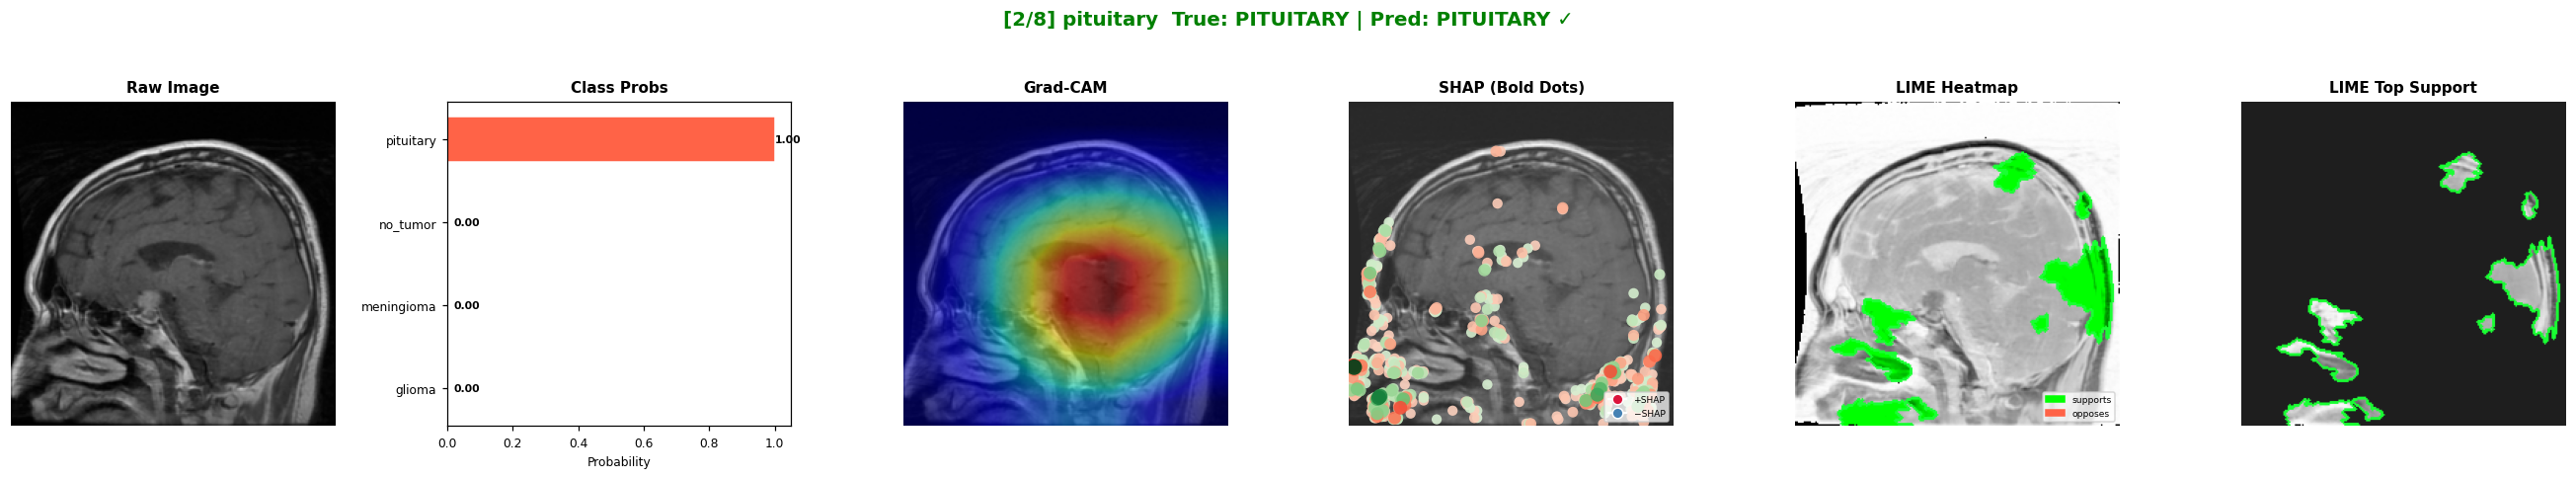

    ✅ Done
  [3/8] pituitary — PITUITARY_0069.mat


  0%|          | 0/2000 [00:00<?, ?it/s]

    💾 Saved → /kaggle/working/xai_test_03_pituitary.png


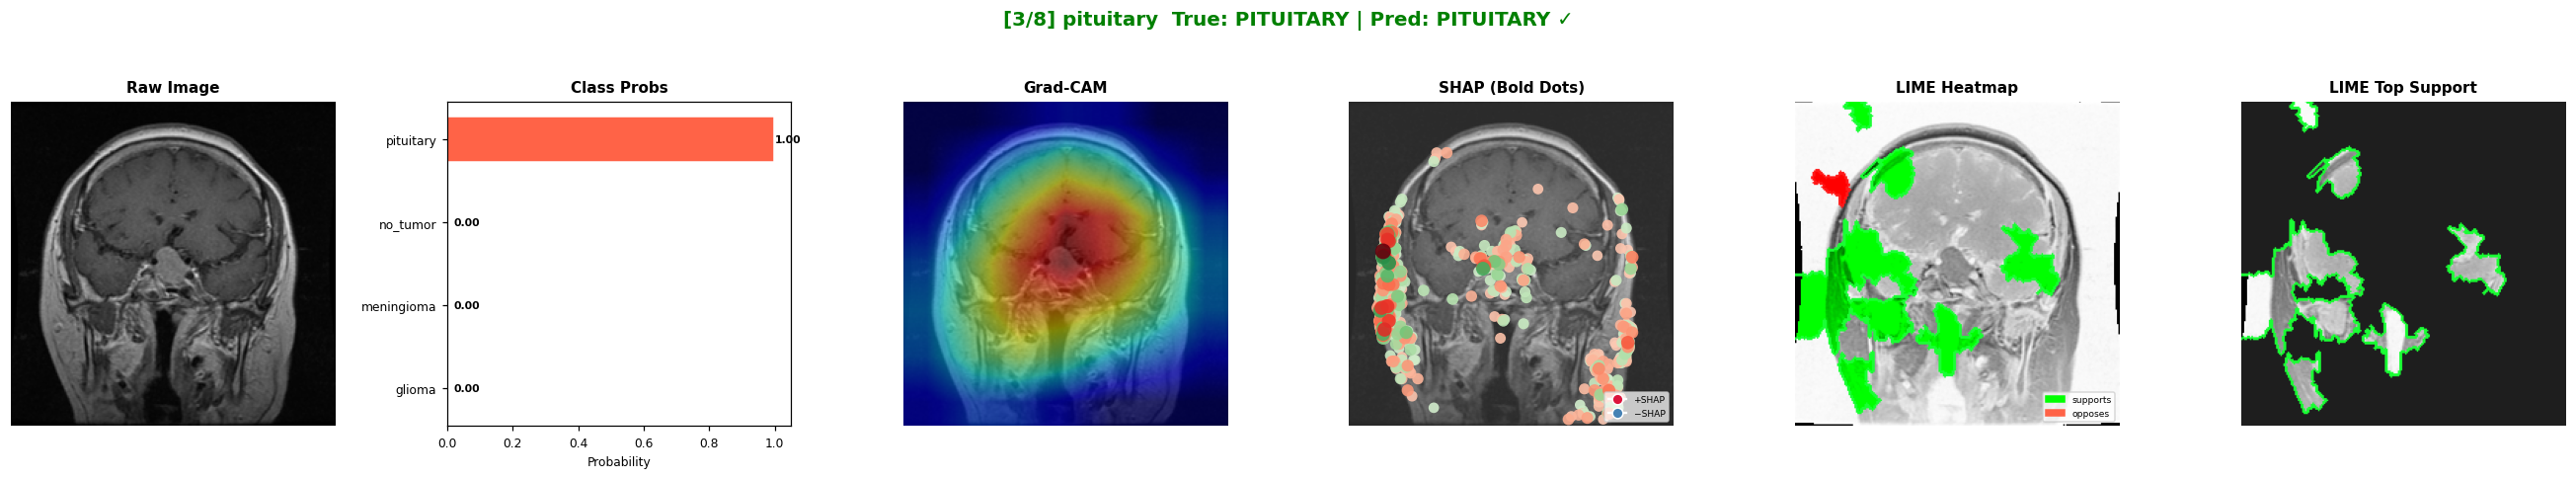

    ✅ Done
  [4/8] glioma — GLIOMA_0015.mat


  0%|          | 0/2000 [00:00<?, ?it/s]

    💾 Saved → /kaggle/working/xai_test_04_glioma.png


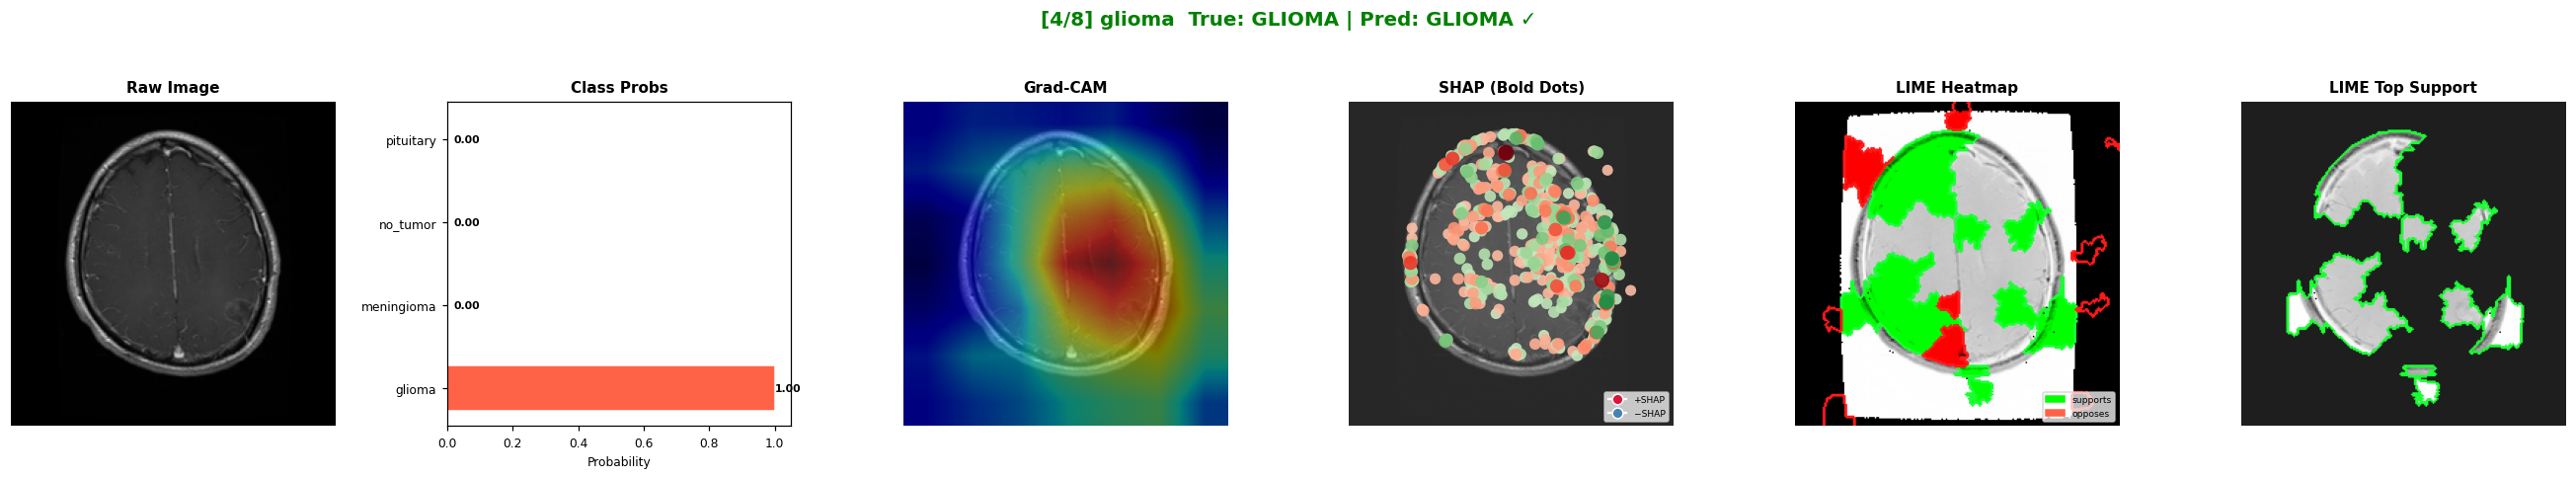

    ✅ Done
  [5/8] meningioma — MENINGIOMA_0059.mat


  0%|          | 0/2000 [00:00<?, ?it/s]

    💾 Saved → /kaggle/working/xai_test_05_meningioma.png


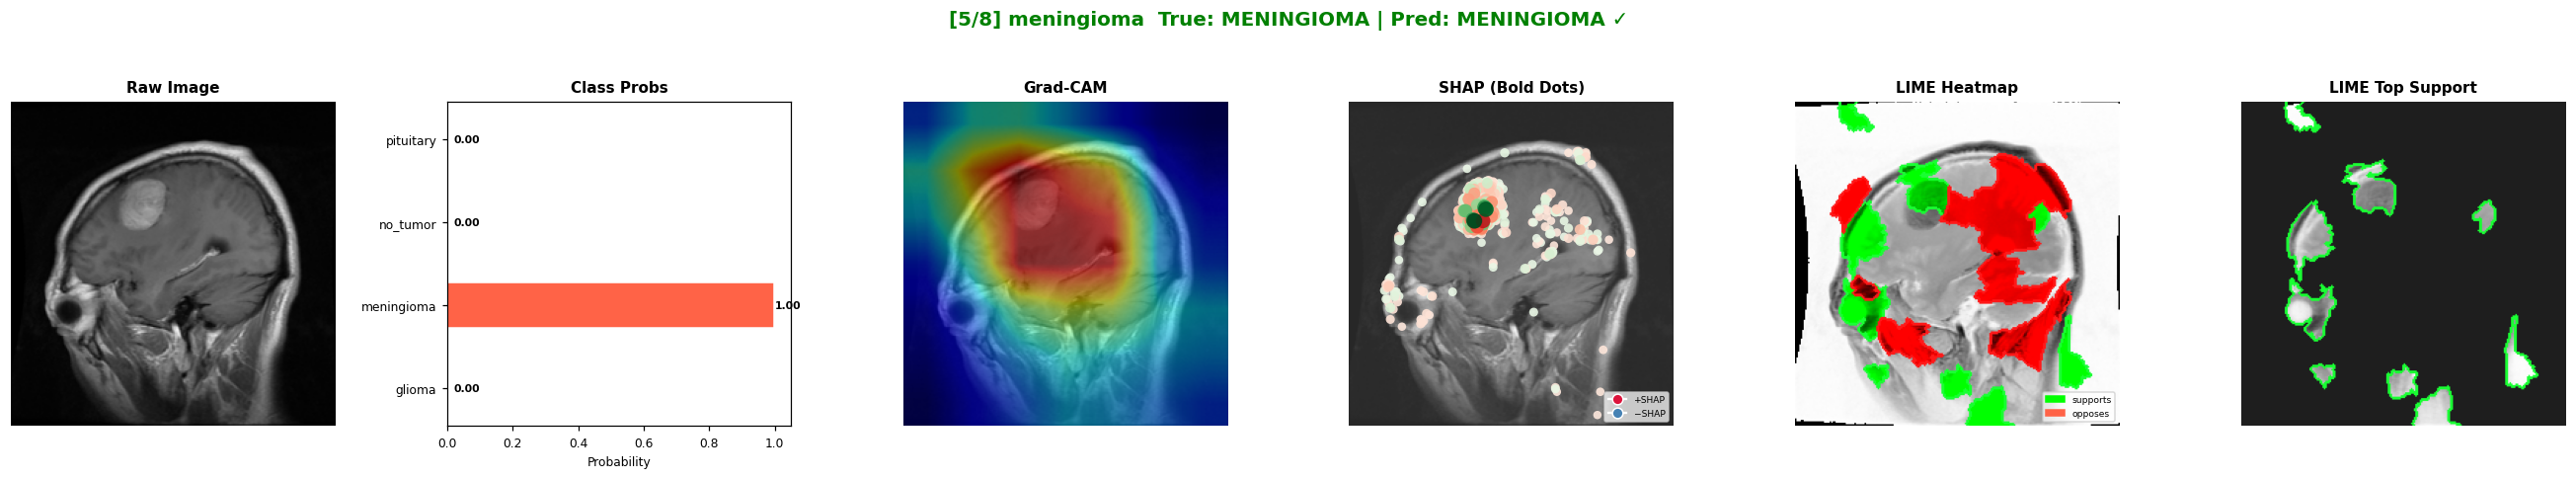

    ✅ Done
  [6/8] no_tumor — NO_TUMOR_0103.mat


  0%|          | 0/2000 [00:00<?, ?it/s]

    💾 Saved → /kaggle/working/xai_test_06_no_tumor.png


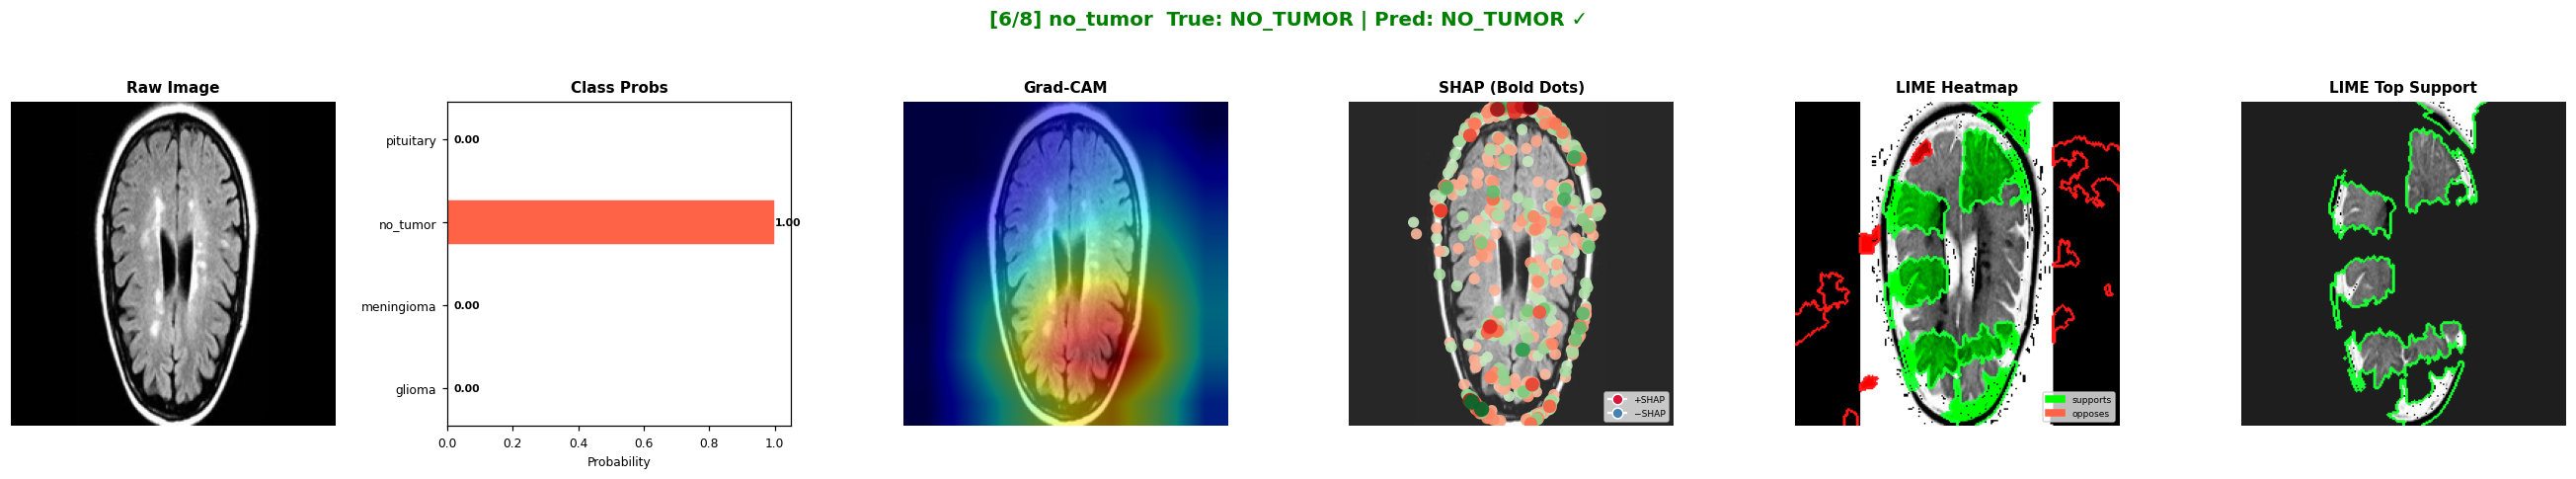

    ✅ Done
  [7/8] no_tumor — NO_TUMOR_0081.mat


  0%|          | 0/2000 [00:00<?, ?it/s]

    💾 Saved → /kaggle/working/xai_test_07_no_tumor.png


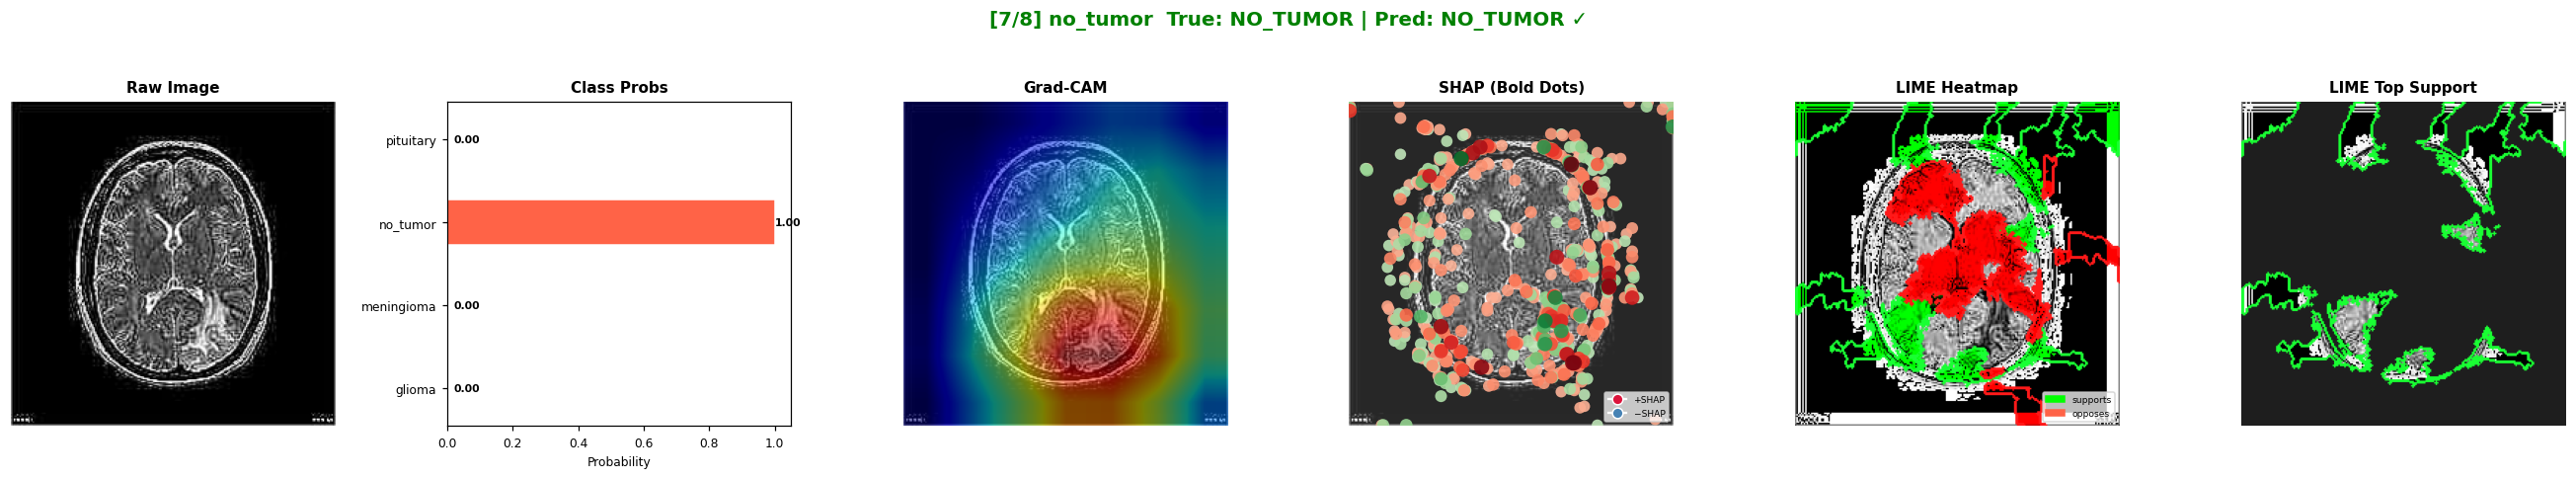

    ✅ Done
  [8/8] meningioma — MENINGIOMA_0009.mat


  0%|          | 0/2000 [00:00<?, ?it/s]

    💾 Saved → /kaggle/working/xai_test_08_meningioma.png


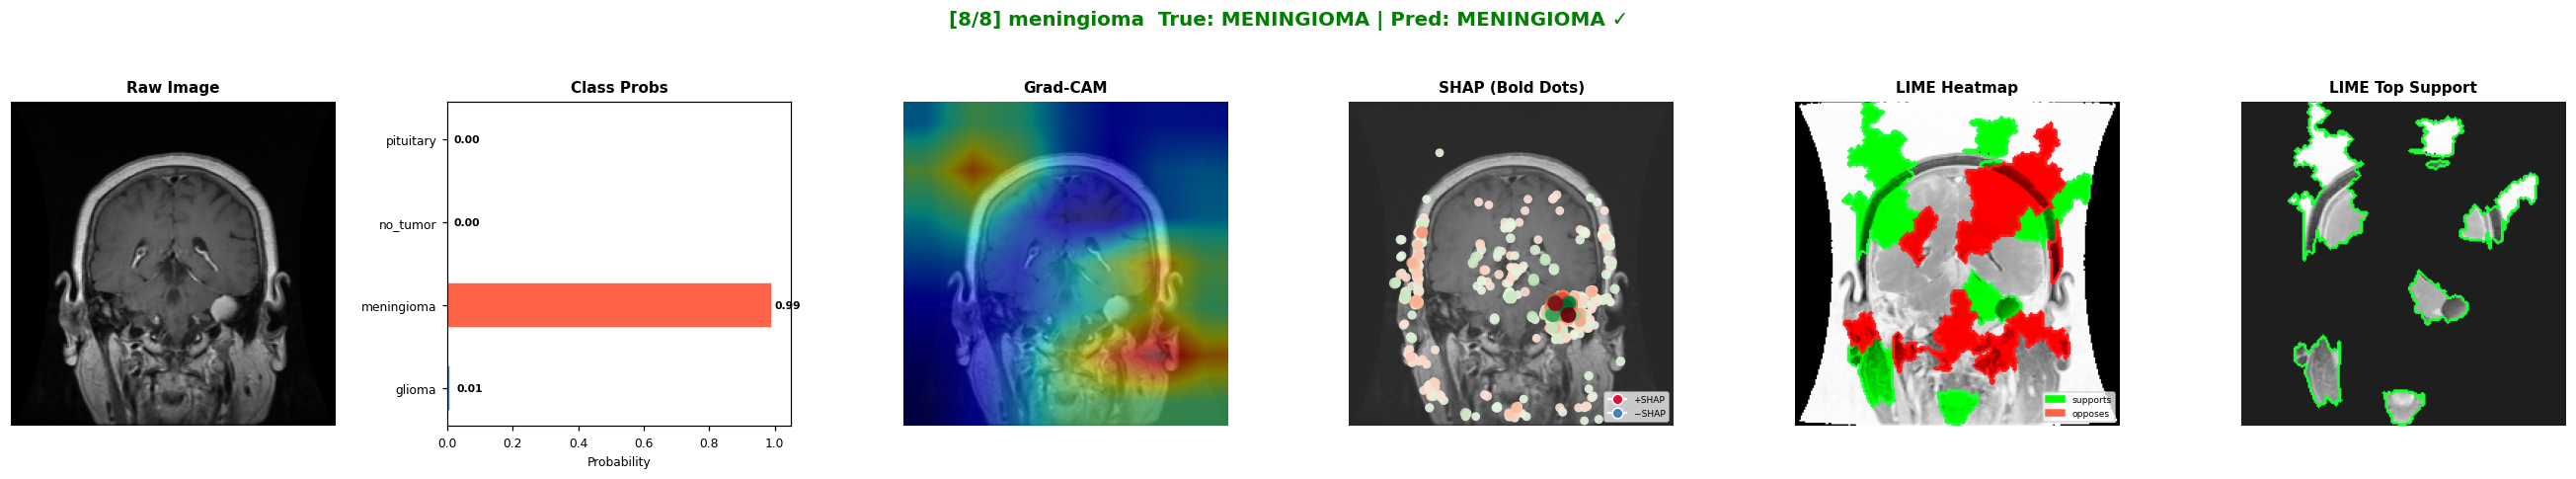

    ✅ Done

XAI grid complete (TEST set only).


In [13]:
def run_test_xai_grid(n_per_class=N_PER_CLASS):
    sampled = sample_balanced(n_per_class)
    n       = len(sampled)
    print(f'\n🔬 Running XAI on {n} TEST images ({n_per_class} per class)')
    print(f'   LIME samples: {LIME_NUM_SAMPLES} | SHAP background: {SHAP_BG_SIZE}')
    print(f'   Estimated time: ~{n * 4}s GPU / ~{n * 25}s CPU\n')

    for idx, (fpath, true_lbl) in enumerate(sampled):
        cls_name = CLASS_NAMES[true_lbl]
        print(f'  [{idx+1}/{n}] {cls_name} — {os.path.basename(fpath)}')
        try:
            pil_rgb  = load_any_image(fpath)
            save_p   = f'/kaggle/working/xai_test_{idx+1:02d}_{cls_name}.png'
            plot_xai_panel(
                pil_rgb,
                true_lbl=true_lbl,
                title_prefix=f'[{idx+1}/{n}] {cls_name}',
                save_path=save_p
            )
            print(f'    ✅ Done')
        except Exception as e:
            import traceback
            print(f'    ❌ Error: {e}')
            traceback.print_exc()

    print('\nXAI grid complete (TEST set only).')


run_test_xai_grid()

In [14]:
def run_upload_ui():
    upload_w    = widgets.FileUpload(
        accept='.mat,.jpg,.jpeg,.png', multiple=True,
        description='Upload Images', layout=widgets.Layout(width='320px')
    )
    predict_btn = widgets.Button(
        description='▶  Predict + XAI', button_style='success',
        layout=widgets.Layout(width='160px')
    )
    output_area = widgets.Output()

    def on_predict(b):
        with output_area:
            clear_output(wait=True)
            files = upload_w.value
            if not files:
                print('⚠️  Please upload at least one file first.')
                return
            items = [(f['name'], bytes(f['content'])) for f in files] \
                    if isinstance(files, tuple) \
                    else [(n, bytes(i['content'])) for n, i in files.items()]
            for filename, raw in items:
                print(f'\n⏳ Processing: {filename} …')
                try:
                    pil_rgb  = load_any_image(raw, filename)
                    save_p   = f'/kaggle/working/upload_{filename}.png'
                    plot_xai_panel(pil_rgb, title_prefix=f'📄 {filename}',
                                   save_path=save_p)
                except Exception as e:
                    import traceback
                    print(f'❌ Error on {filename}:')
                    traceback.print_exc()

    predict_btn.on_click(on_predict)
    print('Upload .mat / .jpg / .png then click ▶ Predict + XAI')
    display(widgets.HBox([upload_w, predict_btn]))
    display(output_area)


run_upload_ui()

Upload .mat / .jpg / .png then click ▶ Predict + XAI


Output()